# Домашнее задание (10 баллов)


(2 балла)
1. закончить реализацию `ClassificationDecisionTree` в decision_tree
    1. реализовать feature_importance_ (для этого метода теста нет, подойдет реализацию любого варианта, базовый способ - рекурсивно суммировать по всем `self.feature_id` `self.q_value_max` и вывести суммы. 
    2. проверить корректность predict 
2. реализовать `BaseSampler`, `ObjectSampler` и `FeatureSampler`. `BaseSampler` - базовый класс, у которого должен быть реализован метода `sample_indices` - вернуть индексы сэмплов. `ObjectSampler` сэплирует объекты, `FeatureSampler` - признаки.
3. реализовать `RandomForestClassifier` в random_forest (predict/predict_proba).

Обратите внимение, что в random_forest в качестве `base_estimator` предполагается использовать `DecisionTreeClassifier` из sklearn, использовать вашу реализацию решающего дерева необязательно. <br> Пример запуска тестов 
- `python -m unittest discover sem_dt_rf/decision_tree/tests`
- `python -m unittest discover sem_dt_rf/random_forest/tests` 

Или через `pytest`
- `python -m pytest sem_dt_rf/decision_tree/tests/test_criterio.py`

In [1]:
import sys
sys.path.extend(['/home/nikita/edu/ai-masters/ml2']) # change your path

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs, make_regression
from sklearn.model_selection import train_test_split

from sem_dt_rf.decision_tree.decision_tree import ClassificationDecisionTree, RegressionDecisionTree
from sem_dt_rf.random_forest.random_forest import RandomForestClassifier

X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = ClassificationDecisionTree()

model.fit(X_train, y_train)
print(f"DT Feature importances: {model.feature_importance_().tolist()}")

y_pred = model.predict(X_test)
accuracy = np.mean(y_test == y_pred)
print(f"DT Accuracy: {accuracy}")

model = RandomForestClassifier(n_estimators=10, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = np.mean(y_test == y_pred)
print(f"RF Accuracy: {accuracy}")

DT Feature importances: [0.45306319800402567, 0.5469368019959744]
DT Accuracy: 0.855
RF Accuracy: 0.91


(1 балл) Для регрессионного дерева необходимо использовать такой критерий:
$$H(R) = \min_c \frac{1}{|R|} \sum_{(x_i, y_i) \in R} (y_i - c)^2$$

Докажите, что минимум H(R) достигается при $c$:

$$ c = \frac{1}{|R|} \sum_{(x_j, y_j) \in R} y_j$$

### Решение

Это задача минимизации среднего квадрата ошибки, минимум достигается в среднем по выборке. Для доказательства занулим производную:
$$ \frac{dH(R)}{dc} = \frac{2}{\left| R \right|} \sum_{y_i \in R} (c - y_i) = 0 \iff c = \frac{1}{\left| R \right|} \sum_{y_i \in R} y_i$$

(3 балла) Реализуйте регрессионное дерево. В качестве критерия необходимо использовать критерий, определённый в пункте 2, в коде есть заглушка `MSECriterion`. В качестве `predict` необходимо использовать среднее значение ответов по всем объектам в листе. В коде нет готовой заглушки, реализуйте по аналогии с `class ClassificationDecisionTree(DecisionTree):`.

Сгенерируйте однопризнаковую выборку для тестирования дерева и покажите работу дерева на этой выборке (пример см. ниже, можно использовать свою версию). Отобразите на одном графике `predict` алгоритма и значение признака. Что меняется при изменении параметра глубины? Сделайте выводы.

In [3]:
X, y = make_regression(n_samples=1000, n_features=2, noise=10, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RegressionDecisionTree(max_depth=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = np.mean((y_test - y_pred) ** 2)
print(f"DT MSE: {mse}")

DT MSE: 345.7954363332615


(4 балла) Протестируйте различные реализации `random_forest` на `fetch_covtype` датасете (можно загрузить с помощью `sklearn.datasets.fetch_covtype`). Возможно, поможет ноутбук с семинара `ensembles_seminar.ipynb`. Для честного сравнения старайтесь использовать похожий набор гиперпараметров.
- ваша реализация (import `RandomForestClassifier as MyRandomForestClassifier` ниже)
- sklearn https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- lightgbm https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMModel.html см. параметр `boosting_type`
- xgboost https://xgboost.readthedocs.io/en/stable/tutorials/rf.html

    Что нужно сделать: 
- Разбейте данные на train и test. 
- Оцените качество алгоритмов по метрике (balanced_accuracy_score)[https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html]
- Оцените время работы `train` и `predict`
- Сделайте выводы

In [4]:
from sem_dt_rf.random_forest.random_forest import RandomForestClassifier as MyRandomForestClassifier

In [5]:
import time
from sklearn.datasets import fetch_covtype
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb

In [6]:
data = fetch_covtype(data_home="../data", download_if_missing=True)
x = data.data
y = data.target - 1

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2269
[LightGBM] [Info] Number of data points in the train set: 464809, number of used features: 53
[LightGBM] [Info] Start training from score -1.008939
[LightGBM] [Info] Start training from score -0.718264
[LightGBM] [Info] Start training from score -2.788115
[LightGBM] [Info] Start training from score -5.354079
[LightGBM] [Info] Start training from score -4.114268
[LightGBM] [Info] Start training from score -3.510169
[LightGBM] [Info] Start training from score -3.343858


/home/nikita/.local/share/mamba/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


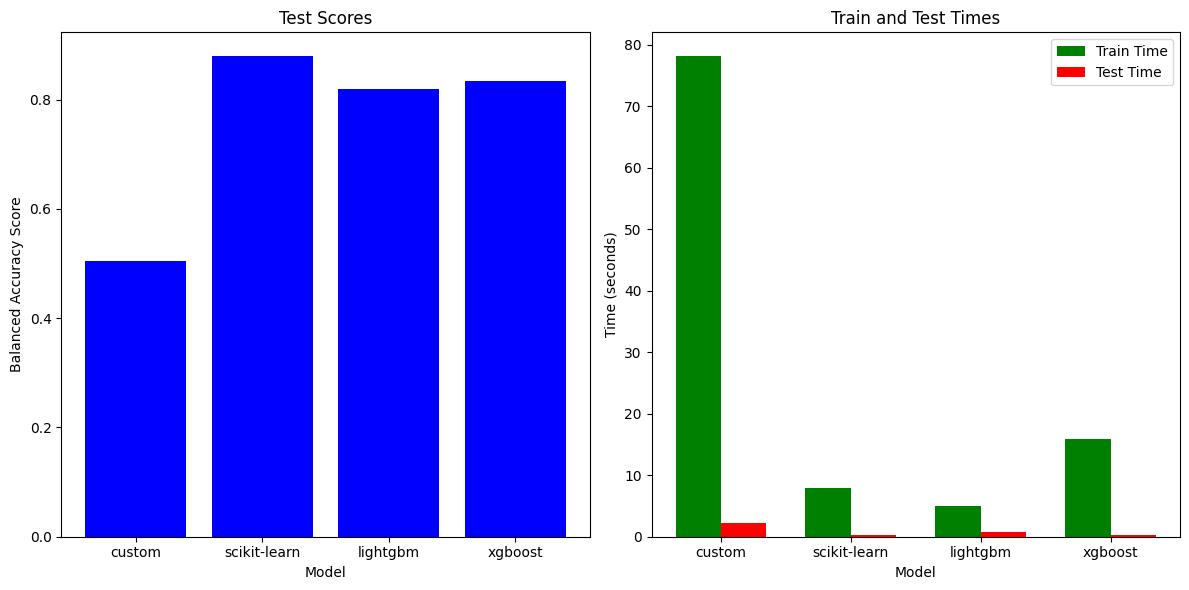

In [8]:
models = {
    "custom": MyRandomForestClassifier(n_estimators=25, max_depth=7),
    "scikit-learn": RandomForestClassifier(n_estimators=10),
    "lightgbm": lgb.LGBMClassifier(n_estimators=100),
    "xgboost": xgb.XGBClassifier(n_estimators=100),
}
train_times = {}
test_scores = {}
test_times = {}

for name, model in models.items():
    start = time.time()
    model.fit(x_train, y_train)
    train_times[name] = time.time() - start

    start = time.time()
    y_pred = model.predict(x_test)
    test_times[name] = time.time() - start

    test_scores[name] = balanced_accuracy_score(y_test, y_pred)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].bar(test_scores.keys(), test_scores.values(), color="blue")
ax[0].set_title("Test Scores")
ax[0].set_ylabel("Balanced Accuracy Score")
ax[0].set_xlabel("Model")


width = 0.35
x = np.arange(len(train_times))

ax[1].bar(x - width / 2, train_times.values(), width, label="Train Time", color="green")
ax[1].bar(x + width / 2, test_times.values(), width, label="Test Time", color="red")

ax[1].set_title("Train and Test Times")
ax[1].set_ylabel("Time (seconds)")
ax[1].set_xlabel("Model")
ax[1].set_xticks(x)
ax[1].set_xticklabels(train_times.keys())
ax[1].legend()

plt.tight_layout()
plt.show()